Actual column names in dataset:
['patientid', 'age', 'bmi', 'exercise_hours_per_week', 'junk_food_intake_per_week']

First 5 rows of the dataset:


,patientid,age,bmi,exercise_hours_per_week,junk_food_intake_per_week
0,1,30,38.3,3,6
1,2,70,38.2,7,0
2,3,63,31.4,6,6
3,4,47,29.0,3,4
4,5,58,20.9,1,7



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientid                  50 non-null     int64  
 1   age                        50 non-null     int64  
 2   bmi                        50 non-null     float64
 3   exercise_hours_per_week    50 non-null     int64  
 4   junk_food_intake_per_week  50 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 2.1 KB
None

Missing values per column:
patientid                    0
age                          0
bmi                          0
exercise_hours_per_week      0
junk_food_intake_per_week    0
dtype: int64


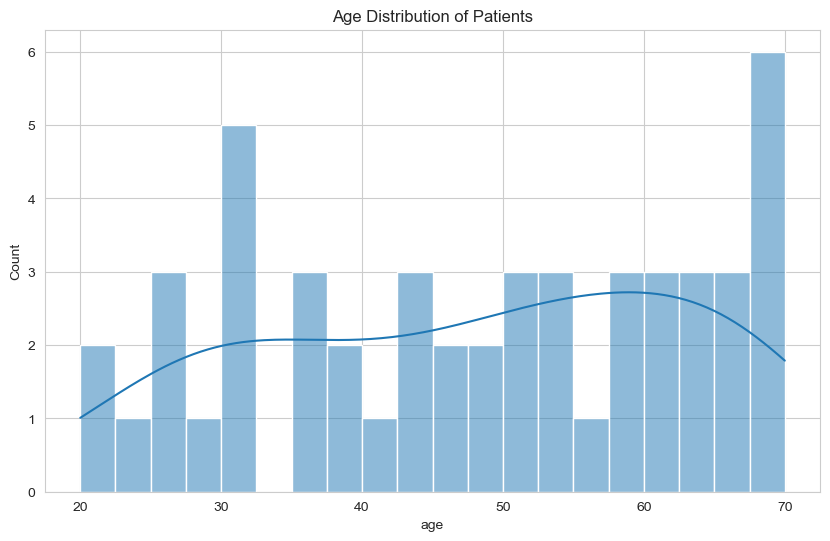

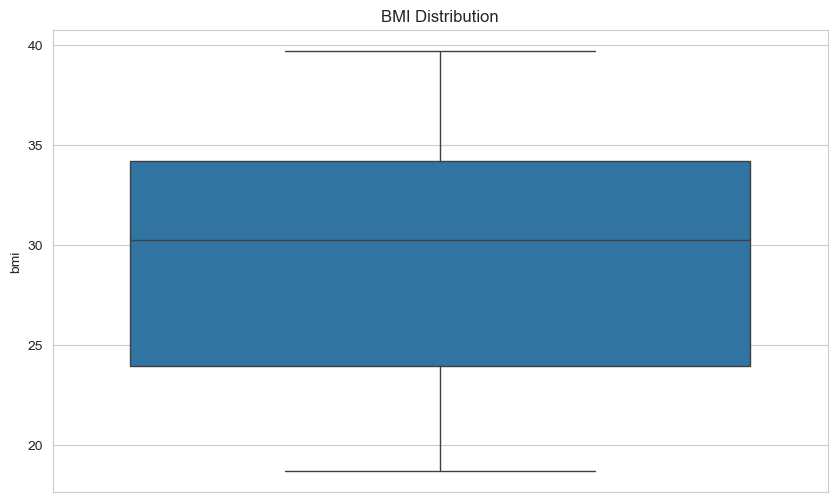

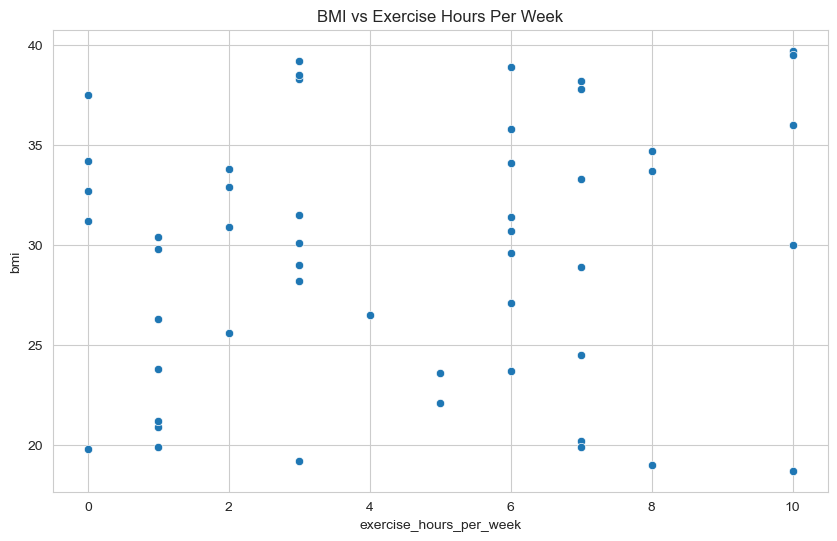

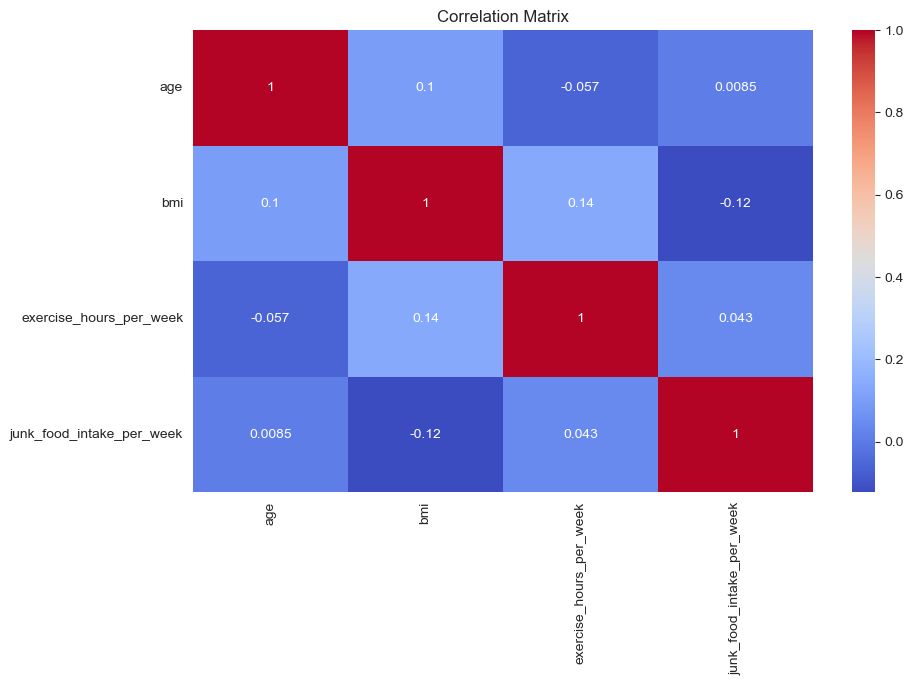

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Part 1: Load and Explore the Dataset

# 1. Load the CSV file using pandas
df = pd.read_csv('patient_lifestyle_dataset.csv')

# First, let's normalize all column names to lowercase with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Actual column names in dataset:")
print(df.columns.tolist())

# 2. Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# 3. Check for missing values and data types
print("\nDataset information:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

## Part 2: Visualize the Dataset

# Create mapping for common column name variations
column_map = {
    'exercise': ['exercise_hours_per_week', 'exercise_hours', 'exercise_per_week', 'exercise'],
    'junkfood': ['junk_food_intake_per_week', 'junk_food', 'fast_food_intake', 'junkfood'],
    'bmi': ['bmi', 'body_mass_index'],
    'age': ['age'],
    'patientid': ['patientid', 'patient_id', 'id']
}

# Function to find the right column name
def find_column(base_name):
    for variant in column_map[base_name]:
        if variant in df.columns:
            return variant
    raise ValueError(f"No matching column found for {base_name}")

# Get actual column names
exercise_col = find_column('exercise')
junkfood_col = find_column('junkfood')
bmi_col = find_column('bmi')
age_col = find_column('age')
patientid_col = find_column('patientid')

# 1. Histogram for Age distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=age_col, bins=20, kde=True)
plt.title('Age Distribution of Patients')
plt.show()

# 2. Boxplot for BMI
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y=bmi_col)
plt.title('BMI Distribution')
plt.show()

# 3. Scatter plot: BMI vs Exercise
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=exercise_col, y=bmi_col)
plt.title('BMI vs Exercise Hours Per Week')
plt.show()

# 4. Heatmap for correlation matrix
plt.figure(figsize=(10, 6))
corr_matrix = df.drop(patientid_col, axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 5. Pairplot (all numerical features)
plt.figure(figsize=(10, 6))
sns.pairplot(df.drop(patientid_col, axis=1))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Additional Visualization 1: Bar plot of average junk food intake by age group
df['age_group'] = pd.cut(df[age_col], bins=[0, 20, 30, 40, 50, 60, 70, 100], 
                        labels=['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+'])
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='age_group', y=junkfood_col)
plt.title('Average Junk Food Intake by Age Group')
plt.show()

# Additional Visualization 2: Violin plot of Exercise Hours by BMI Category
df['bmi_category'] = pd.cut(df[bmi_col], bins=[0, 18.5, 25, 30, 100], 
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='bmi_category', y=exercise_col)
plt.title('Exercise Hours Distribution by BMI Category')
plt.show()

## Part 3: Data Preprocessing

# 1. Drop PatientID and temporary columns
df = df.drop([patientid_col, 'age_group', 'bmi_category'], axis=1)

# 2. Standardize the remaining features using StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_features, columns=df.columns)

## Part 4: Clustering

# 1. Use K-Means to segment the patients (try n_clusters = 3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_scaled)

# 2. Assign cluster labels and add them to the dataframe
df['cluster'] = kmeans.labels_

# 3. Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=bmi_col, y=exercise_col, hue='cluster', palette='viridis')
plt.title('Patient Clusters: BMI vs Exercise Hours')
plt.show()

## Part 5: Interactive Input

# Ask user to input a new patient's details
print("\nPredicting cluster for a new patient:")
age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
exercise = float(input("Enter Exercise Hours Per Week: "))
junk_food = float(input("Enter Junk Food Intake Per Week: "))

# Create a dataframe for the new patient
new_patient = pd.DataFrame([[age, bmi, exercise, junk_food]], 
                          columns=[age_col, bmi_col, exercise_col, junkfood_col])

# Scale the new patient data
new_patient_scaled = scaler.transform(new_patient)

# Predict the cluster
cluster = kmeans.predict(new_patient_scaled)[0]
print(f"\nThe new patient belongs to Cluster {cluster}")

# Save the updated dataset with clusters
df.to_csv('patient_lifestyle_dataset_with_clusters.csv', index=False)